In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.colors as mcolors
from scipy import stats
import nibabel as nib
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr
import random
from statsmodels.stats.multitest import multipletests
random.seed(42)

In [2]:
atlas = pd.read_csv('../../dataset/rat/rat_brainregions.csv')
regions = pd.read_csv('../../dataset/rat/rat_brainatlas.csv', header=None)
parcels = pd.read_csv('../../dataset/rat/20250918parcel.csv')

In [3]:
regions.columns = ['region', 'fullname', 'category', 'receptor']

In [4]:
age_H = pd.read_csv('../../derivatives/rat/hurst_roi.csv')
age_H=age_H[age_H.motion<0.012]
allregions = age_H.columns[:50]

In [5]:
originalH = pd.DataFrame(age_H[age_H.run==1].iloc[:, :50].mean().values)
originalH.columns = ['hurst']
custom_colors = [(0, "white"),  (1, "blue")]  # Blue to white to red
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
norm = mcolors.Normalize(vmin=originalH.hurst.values.min(), vmax=originalH.hurst.values.max())
colors = cmap(norm(originalH.hurst.values))
hex_colors = [mcolors.to_hex(color) for color in colors] # Flatten and convert to list
originalH['color'] = hex_colors

In [6]:
alcohol_effect = pd.read_csv('../../derivatives/rat/alcohol_motionlimited_effect_roi.csv') #
alcohol_effect['region'] = allregions
alcohol_effect['pvalue'] = alcohol_effect['results[[4]]']
alcohol_effect['parcel'] = np.arange(1,51)
alcohol_effect = pd.merge(alcohol_effect, parcels, on='parcel', how='left')
for group in ['cortex', 'subcortex']:
    pvals = alcohol_effect.loc[alcohol_effect.group == group, 'pvalue']
    # Perform FDR correction
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    # Assign corrected p-values back to the DataFrame
    alcohol_effect.loc[alcohol_effect.group == group, 'pvalue_fdr'] = pvals_corrected
    alcohol_effect.loc[alcohol_effect.group == group, 'reject_fdr'] = reject

In [7]:
custom_order = ['s', 'a', 'l']
alcohol_effect['sa'] = pd.Categorical(alcohol_effect['sa'], categories=custom_order, ordered=True)
alcohol_effect = alcohol_effect.sort_values(['sa', 'alcohol'])
alcohol_effect['region'] = alcohol_effect['parcel'].astype('str') + '_' + alcohol_effect['region_y']

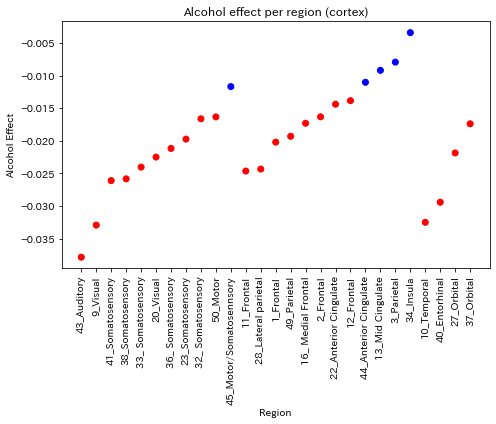

In [8]:
#Fig 1E
cortex_data = alcohol_effect[alcohol_effect.group == 'cortex']

# Numeric positions for x-axis
x_pos = np.arange(len(cortex_data))
y = cortex_data.alcohol
labels = cortex_data.region

# Set colors: red if significant after FDR, blue otherwise
colors = ['red' if r else 'blue' for r in cortex_data.reject_fdr]

plt.figure(figsize=(7, 6))
plt.scatter(x_pos, y, color=colors)

# X-axis labels
plt.xticks(ticks=x_pos, labels=labels, rotation=90)
plt.xlabel("Region")
plt.ylabel("Alcohol Effect")
plt.title("Alcohol effect per region (cortex)")
plt.tight_layout()
plt.savefig('alcoholeffect_cortex.eps')

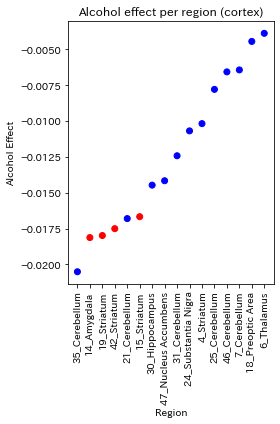

In [9]:
#Fig S3B
cortex_data = alcohol_effect[alcohol_effect.group == 'subcortex']

# Numeric positions for x-axis
x_pos = np.arange(len(cortex_data))
y = cortex_data.alcohol
labels = cortex_data.region

# Set colors: red if significant after FDR, blue otherwise
colors = ['red' if r else 'blue' for r in cortex_data.reject_fdr]

plt.figure(figsize=(4, 6))
plt.scatter(x_pos, y, color=colors)

# X-axis labels
plt.xticks(ticks=x_pos, labels=labels, rotation=90)
plt.xlabel("Region")
plt.ylabel("Alcohol Effect")
plt.title("Alcohol effect per region (cortex)")
plt.tight_layout()
plt.savefig('alcoholeffect_subcortex.eps')

In [10]:
alcohol_effect_copy = alcohol_effect.copy()
alcohol_effect_copy = alcohol_effect_copy[alcohol_effect_copy.alcohol<0]
custom_colors = [(0, "blue"),  (1, "white")]  # Blue to white to red
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
norm = mcolors.Normalize(vmin=alcohol_effect_copy.alcohol.values.min(), vmax=alcohol_effect_copy.alcohol.values.max())
colors = cmap(norm(alcohol_effect_copy.alcohol.values))
hex_colors = [mcolors.to_hex(color) for color in colors] # Flatten and convert to list
alcohol_effect_copy['color'] = hex_colors

In [11]:
subcortex = [(i-1) for i in [6,7,14,15,18,19,21,24,25,30,31,35,42,46]]
cortex = [i for i in np.arange(50) if i not in subcortex]

In [12]:
columns_to_plot = ['baseline', 'saline', 'dose1', 'dose2', 'dose3']
boxplot_colors = ['gray', "#ADD8E6", "#87CEEB", "#4682B4", "#00008B"]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


ANOVA Results:
F-statistic: 9.108830760995733
p-value: 6.628962507374644e-06


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
baseline  dose1   0.0346 0.2646 -0.0133  0.0825  False
baseline  dose2  -0.0504 0.0342 -0.0983 -0.0025   True
baseline  dose3  -0.0522  0.026 -0.1001 -0.0043   True
baseline saline  -0.0164 0.8723 -0.0643  0.0315  False
   dose1  dose2  -0.0851    0.0  -0.133 -0.0372   True
   dose1  dose3  -0.0868    0.0 -0.1347 -0.0389   True
   dose1 saline   -0.051 0.0314 -0.0989 -0.0031   True
   dose2  dose3  -0.0017    1.0 -0.0496  0.0462  False
   dose2 saline   0.0341 0.2798 -0.0138   0.082  False
   dose3 saline   0.0358 0.2336 -0.0121  0.0837  False
------------------------------------------------------
P-value: 0.2645622571823669
P-value: 0.0341613234121624
P-value: 0.0260160292759092
P-value: 0.8723005102116900
P-value: 0.0000473962028875
P-value: 0.0000324059268796
P-value: 0.0313559424283227
P-value: 0.9999746494916203
P-valu

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


ANOVA Results:
F-statistic: 17.506205664863668
p-value: 4.217217959103766e-12
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
baseline  dose1   0.0168 0.6992 -0.0191  0.0527  False
baseline  dose2  -0.0657    0.0 -0.1016 -0.0298   True
baseline  dose3  -0.0695    0.0 -0.1054 -0.0336   True
baseline saline  -0.0239 0.3592 -0.0598  0.0121  False
   dose1  dose2  -0.0825    0.0 -0.1184 -0.0466   True
   dose1  dose3  -0.0863    0.0 -0.1222 -0.0503   True
   dose1 saline  -0.0407 0.0179 -0.0766 -0.0047   True
   dose2  dose3  -0.0038 0.9984 -0.0397  0.0321  False
   dose2 saline   0.0418 0.0135  0.0059  0.0778   True
   dose3 saline   0.0456 0.0053  0.0097  0.0816   True
------------------------------------------------------
P-value: 0.6991896172261308
P-value: 0.0000113202635332
P-value: 0.0000029491172034
P-value: 0.3591892891463387
P-value: 0.0000000200616203
P-value: 0.0

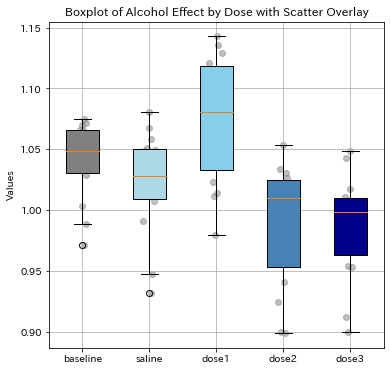

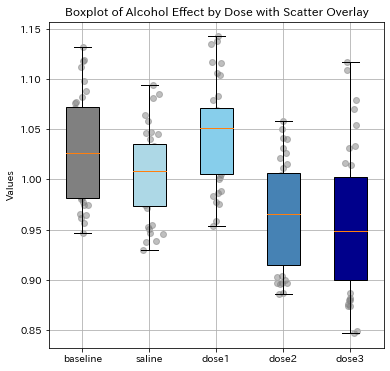

In [13]:
#Fig 1C
for k,x in enumerate([subcortex, cortex]):
    hurst = pd.concat([age_H.iloc[:, x], age_H['H_combined53']], axis=1)
    hurst = hurst.groupby('H_combined53').mean().reset_index(drop=True).T
    hurst.columns = ['baseline', 'saline', 'dose1', 'dose2', 'dose3']
    plt.figure(figsize=(6, 6))
    boxplot = plt.boxplot(
        [hurst[col] for col in columns_to_plot],
        labels=columns_to_plot,
        patch_artist=True
    )
    for patch, color in zip(boxplot['boxes'], boxplot_colors):
        patch.set_facecolor(color)
    for i, col in enumerate(columns_to_plot):
        x = np.random.normal(i + 1, 0.05, size=len(hurst[col]))  # Add jitter to x position
        plt.scatter(x, hurst[col], alpha=0.5, color='gray')
    plt.ylabel('Values')
    plt.title('Boxplot of Alcohol Effect by Dose with Scatter Overlay')
    plt.grid(True)
    plt.savefig('originalvalue(motionregressedout).eps')
    anova_result = stats.f_oneway(
        hurst['baseline'],
        hurst['saline'],
        hurst['dose1'],
        hurst['dose2'],
        hurst['dose3']
    )
    print(f'ANOVA Results:\nF-statistic: {anova_result.statistic}\np-value: {anova_result.pvalue}')
    if k==0:
        plt.savefig('subcortex_alcoholvalues.eps')
    else:
        plt.savefig('cortex_alcoholvalues.eps')

    df_melted = pd.melt(hurst[columns_to_plot], var_name='Dose', value_name='Values')
    tukey_result = pairwise_tukeyhsd(endog=df_melted['Values'], groups=df_melted['Dose'], alpha=0.05)
    print(tukey_result)
    for i in range(len(tukey_result.pvalues)):
        print(f'P-value: {tukey_result.pvalues[i]:.16f}')  # Print p-value with 16 decimal places

In [14]:
receptor = pd.read_csv('../../derivatives/rat/receptor_mean.csv')

In [15]:
subcortex = ['TS', 'DS', 'CERE', 'BLA', 'CEA','Crus2', 'CPuAM', 'HIPP-fi','VM','M', 'CpuAM', 'PA', 'VL', 'ZI', 'IC','SC', 'DG','PrS', 'CA','PaS','MeA','AcbSh', 'MS', 'CpuDM', 'CpuVL', 'CPuD', 'SN']
subcortexid = []
for i in np.arange(atlas.shape[0]):
    rs = atlas.iloc[i, :].values
    for r in rs:
        if r in subcortex:
            subcortexid.append(i)

In [16]:
receptor = receptor.loc[:, ['name', 'fmol/mg']].groupby('name').median().reset_index()

In [17]:
receptor_values = []
brain_regions = []
for i in np.arange(50):
    region_values = []
    region = atlas.iloc[i, :]
    for r in region:
        if r in regions.region.values:
            recep = regions[regions.region==r].receptor.values
            for rec in recep:
                if receptor[receptor['name']==rec].shape[0]>0:
                    region_values.append(receptor[receptor['name']==rec]['fmol/mg'].values[0])
    if len(region_values)>0:
        brain_regions.append(i+1)
    print([region.values, region_values])
    receptor_values.append(np.median(region_values))

[array([1, 'Fr3', 'S1', nan, nan, nan, nan, nan, nan], dtype=object), [2487.1525, 2493.4325]]
[array([2, 'Fr3', 'M1', nan, nan, nan, nan, nan, nan], dtype=object), [2487.1525, 2662.195]]
[array([3, 'M2', 'V2', 'RSC', 'PtPD', 'LPtA', 'MPtA', 'S1', nan],
      dtype=object), [2760.255, 2409.325, 2955.5525000000002, 2394.63, 2248.3075, 2493.4325]]
[array([4, 'CPuAM', nan, nan, nan, nan, nan, nan, nan], dtype=object), []]
[array([5, 'SC', 'IC', nan, nan, nan, nan, nan, nan], dtype=object), []]
[array([6, 'VM', 'MPA', 'PLH', 'ZI', 'VL', nan, nan, nan], dtype=object), []]
[array([7, 'CERE', 'Crus2', nan, nan, nan, nan, nan, nan], dtype=object), []]
[array([8, 'Tu', 'Pir', nan, nan, nan, nan, nan, nan], dtype=object), [1914.81, 2108.65, 2060.31]]
[array([9, 'V1', 'V2', nan, nan, nan, nan, nan, nan], dtype=object), [2311.55, 2244.32, 2614.55, 2409.325, 2955.5525000000002, 2394.63]]
[array([10, 'TeA', 'DLEnt', 'PRh', 'Ect', nan, nan, nan, nan], dtype=object), [2661.2525, 2447.62, 2306.2225, 267

/Users/monaminishio/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/monaminishio/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Correlation coefficient: -0.43825879163735365
P-value: 0.015417826271382072


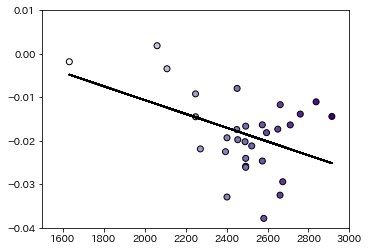

In [18]:
#Fig 1G
alcohol_effect = alcohol_effect.sort_index()
figure = plt.figure(figsize=(5.5,4))
df = pd.DataFrame([alcohol_effect.alcohol.values, receptor_values]).T
df.columns = ['alcohol', 'receptor']
df = df.dropna()
plt.scatter(df.receptor.values, df.alcohol.values, 
                      c=df.receptor.values, cmap="Purples", edgecolors='k')
corr_coef, p_value = pearsonr(df['receptor'],df['alcohol'])
print(f"Correlation coefficient: {corr_coef}")
print(f"P-value: {p_value}")
y = df['alcohol']
x = df['receptor']
slope, intercept = np.polyfit(x, y, 1)  # Fit line (degree=1 for linear)
line = slope * x + intercept
for t in np.arange(len(x)):
    plt.plot(x.values, line.values, color='black', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.ylim(-0.04, 0.01)
plt.xlim(1500, 3000)
plt.savefig('correlation.eps')